# Exploratory Data Analysis
Loads the Twibot-22 dataset and explores distributions, class balance, and initial patterns.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "pre-processed"

DATASETS = {
    "cresci_2015": {
        "users": DATA_DIR / "cresci_2015" / "users_cresci_2015.csv",
        "tweets": DATA_DIR / "cresci_2015" / "tweets_cresci_2015.csv",
    },
    "cresci_2017": {
        "users": DATA_DIR / "cresci_2017" / "users_cresci_2017.csv",
        "tweets": DATA_DIR / "cresci_2017" / "tweets_cresci_2017.csv",
    },
    "twibot_2020": {
        "users": DATA_DIR / "twibot_2020" / "users_twibot_20.csv",
        "tweets": DATA_DIR / "twibot_2020" / "tweets_twibot_20.csv",
    },
    "twibot_2022": {
        "users": DATA_DIR / "twibot_2022" / "users_twibot_22.csv",
        "tweets": DATA_DIR / "twibot_2022" / "tweets_twibot_22.csv",
    },
}

for name, paths in DATASETS.items():
    print(name)
    print("  users exists: ", paths["users"].exists(), paths["users"])
    print("  tweets exists:", paths["tweets"].exists(), paths["tweets"])

cresci_2015
  users exists:  True ../data/pre-processed/cresci_2015/users_cresci_2015.csv
  tweets exists: True ../data/pre-processed/cresci_2015/tweets_cresci_2015.csv
cresci_2017
  users exists:  True ../data/pre-processed/cresci_2017/users_cresci_2017.csv
  tweets exists: True ../data/pre-processed/cresci_2017/tweets_cresci_2017.csv
twibot_2020
  users exists:  True ../data/pre-processed/twibot_2020/users_twibot_20.csv
  tweets exists: True ../data/pre-processed/twibot_2020/tweets_twibot_20.csv
twibot_2022
  users exists:  True ../data/pre-processed/twibot_2022/users_twibot_22.csv
  tweets exists: True ../data/pre-processed/twibot_2022/tweets_twibot_22.csv


## Load Datasets

In [2]:
con = duckdb.connect()

user_frames  = []
total_tweets = 0

for dataset_name, paths in DATASETS.items():
    users = pd.read_csv(paths["users"], low_memory=False)
    users["dataset"] = dataset_name
    users["user_id"]  = users["user_id"].astype(str)
    user_frames.append(users)

    if dataset_name == "twibot_2022":
        tweet_path = str(paths["tweets"])
        con.execute(f"""
            CREATE VIEW tweets_{dataset_name} AS
            SELECT CAST(tweet_id             AS VARCHAR) AS tweet_id,
                   CAST(user_id              AS VARCHAR) AS user_id,
                   text,
                   created_at,
                   CAST(in_reply_to_user_id  AS VARCHAR) AS in_reply_to_user_id,
                   '{dataset_name}' AS dataset
            FROM read_csv_auto('{tweet_path}')
        """)
        n_tweets = 88_217_457  # known from cleaning
        total_tweets += n_tweets
        print(f"{dataset_name}: {len(users):,} users, {n_tweets:,} tweets (full — DuckDB view)")
    else:
        tweets = pd.read_csv(paths["tweets"], low_memory=False)
        tweets["dataset"]  = dataset_name
        tweets["user_id"]  = tweets["user_id"].astype(str)
        if "tweet_id" in tweets.columns:
            tweets["tweet_id"] = tweets["tweet_id"].astype(str)
        con.register(f"tweets_{dataset_name}", tweets)
        total_tweets += len(tweets)
        print(f"{dataset_name}: {len(users):,} users, {len(tweets):,} tweets")

users_all = pd.concat(user_frames, ignore_index=True, sort=False)

con.execute("""
    CREATE VIEW tweets_all AS
        SELECT tweet_id, user_id, text, created_at, in_reply_to_user_id, dataset
          FROM tweets_cresci_2015
        UNION ALL
        SELECT tweet_id, user_id, text, created_at, in_reply_to_user_id, dataset
          FROM tweets_cresci_2017
        UNION ALL
        SELECT tweet_id, user_id, text, created_at, in_reply_to_user_id, dataset
          FROM tweets_twibot_2020
        UNION ALL
        SELECT tweet_id, user_id, text, created_at, in_reply_to_user_id, dataset
          FROM tweets_twibot_2022
""")

print(f"\nCombined users:  {users_all.shape}")
print(f"Combined tweets: {total_tweets:,} rows (twibot_2022 via DuckDB view)")


cresci_2015: 5,301 users, 2,827,757 tweets
cresci_2017: 14,368 users, 6,637,615 tweets
twibot_2020: 11,826 users, 1,999,788 tweets
twibot_2022: 1,000,000 users, 88,217,457 tweets (full — DuckDB view)

Combined users:  (1031495, 15)
Combined tweets: 99,682,617 rows (twibot_2022 via DuckDB view)


## Column availability

In [3]:
presence_rows = []

for dataset_name, paths in DATASETS.items():
    cols = pd.read_csv(paths["users"], nrows=0).columns

    for col in cols:
        presence_rows.append({
            "dataset": dataset_name,
            "column": col,
            "present": True,
        })

user_presence_long = pd.DataFrame(presence_rows)

user_presence = (
    user_presence_long
    .pivot_table(
        index="column",
        columns="dataset",
        values="present",
        aggfunc="any",
        fill_value=False,
    )
    .reset_index()
)

user_presence["num_datasets"] = user_presence[list(DATASETS.keys())].sum(axis=1)

user_presence = user_presence.sort_values(
    ["num_datasets", "column"],
    ascending=[False, True],
)

display(user_presence)

dataset,column,cresci_2015,cresci_2017,twibot_2020,twibot_2022,num_datasets
0,created_at,True,True,True,True,4
1,default_profile_image,True,True,True,True,4
2,description,True,True,True,True,4
3,followers_count,True,True,True,True,4
4,friends_count,True,True,True,True,4
5,label,True,True,True,True,4
6,listed_count,True,True,True,True,4
7,location,True,True,True,True,4
8,screen_name,True,True,True,True,4
9,source,True,True,True,True,4


## Dataset Sizes

In [4]:
dataset_size_summary = (
    users_all
    .groupby("dataset")
    .agg(
        users=("user_id", "nunique"),
        user_rows=("user_id", "count"),
    )
    .reset_index()
)

tweet_size_summary = con.execute("""
    SELECT
        dataset,
        COUNT(*) AS tweets,
        COUNT(DISTINCT user_id) AS tweeting_users
    FROM tweets_all
    GROUP BY dataset
    ORDER BY dataset
""").df()

size_summary = dataset_size_summary.merge(
    tweet_size_summary,
    on="dataset",
    how="left",
)

size_summary["tweets_per_user"] = (
    size_summary["tweets"] / size_summary["users"]
).round(2)

size_summary["pct_users_with_tweets"] = (
    size_summary["tweeting_users"] / size_summary["users"] * 100
).round(2)

display(size_summary)

,dataset,users,user_rows,tweets,tweeting_users,tweets_per_user,pct_users_with_tweets
0,cresci_2015,5301,5301,2827757,5148,533.44,97.11
1,cresci_2017,14368,14368,6637615,10197,461.97,70.97
2,twibot_2020,11826,11826,1999788,11746,169.10,99.32
3,twibot_2022,1000000,1000000,88217457,933872,88.22,93.39


## Label Balance

Label counts:


label,bot,human,All
dataset,,,
cresci_2015,3987,1314,5301
cresci_2017,10894,3474,14368
twibot_2020,6589,5237,11826
twibot_2022,139943,860057,1000000
All,161413,870082,1031495


Label percentages:


label,bot,human
dataset,,
cresci_2015,75.21,24.79
cresci_2017,75.82,24.18
twibot_2020,55.72,44.28
twibot_2022,13.99,86.01


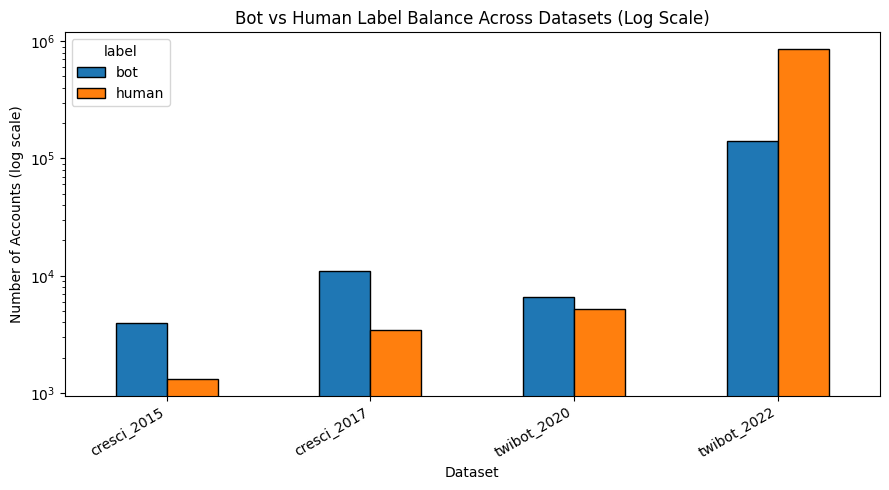

In [5]:
label_counts = pd.crosstab(
    users_all["dataset"],
    users_all["label"],
    margins=True,
)

label_pct = (
    pd.crosstab(
        users_all["dataset"],
        users_all["label"],
        normalize="index",
    )
    .mul(100)
    .round(2)
)

print("Label counts:")
display(label_counts)

print("Label percentages:")
display(label_pct)

label_plot = pd.crosstab(users_all["dataset"], users_all["label"])

ax = label_plot.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black",
)

ax.set_yscale("log")  # KEY FIX

plt.title("Bot vs Human Label Balance Across Datasets (Log Scale)")
plt.xlabel("Dataset")
plt.ylabel("Number of Accounts (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Data Missingness

In [6]:
missing_rows = []

for dataset_name, group in users_all.groupby("dataset"):
    for col in group.columns:
        missing_rows.append({
            "dataset": dataset_name,
            "column": col,
            "missing_count": group[col].isna().sum(),
            "missing_pct": round(group[col].isna().mean() * 100, 2),
        })

missing_users = pd.DataFrame(missing_rows)

display(
    missing_users
    .sort_values(["dataset", "missing_pct"], ascending=[True, False])
    .query("missing_pct > 0")
)

,dataset,column,missing_count,missing_pct
9,cresci_2015,verified,5301,100.00
12,cresci_2015,default_profile_image,5276,99.53
10,cresci_2015,description,1216,22.94
11,cresci_2015,location,1212,22.86
24,cresci_2017,verified,14357,99.92
27,cresci_2017,default_profile_image,14290,99.46
26,cresci_2017,location,6684,46.52
25,cresci_2017,description,5744,39.98
56,twibot_2022,location,291564,29.16
55,twibot_2022,description,124262,12.43


## Tweet Coverage

In [7]:
# Tweet coverage by dataset and label

tweeting_users = con.execute("""
    SELECT dataset, user_id, TRUE AS has_tweets_in_file
    FROM tweets_all
    GROUP BY dataset, user_id
""").df()

tweeting_users["user_id"] = tweeting_users["user_id"].astype(str)

users_with_tweet_flag = users_all.merge(
    tweeting_users,
    on=["dataset", "user_id"],
    how="left",
)

users_with_tweet_flag["has_tweets_in_file"] = (
    users_with_tweet_flag["has_tweets_in_file"].fillna(False)
)

display(
    pd.crosstab(
        [users_with_tweet_flag["dataset"], users_with_tweet_flag["label"]],
        users_with_tweet_flag["has_tweets_in_file"],
        margins=True,
    )
)

display(
    users_with_tweet_flag
    .groupby(["dataset", "label"])["has_tweets_in_file"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("pct_with_tweets")
)


has_tweets_in_file  False    True      All
dataset     label                         
cresci_2015 bot        22    3965     3987
            human     131    1183     1314
cresci_2017 bot      1780    9114    10894
            human    2391    1083     3474
twibot_2020 bot        28    6561     6589
            human      52    5185     5237
twibot_2022 bot     24684  115259   139943
            human   41444  818613   860057
All                 70532  960963  1031495

pct_with_tweets
dataset     label                
cresci_2015 bot             99.45
            human           90.03
cresci_2017 bot             83.66
            human           31.17
twibot_2020 bot             99.58
            human           99.01
twibot_2022 bot             82.36
            human           95.18

## Account metadata comparison

In [8]:
candidate_user_cols = [
    "followers_count",
    "friends_count",
    "statuses_count",
    "listed_count",
]

candidate_user_cols = [c for c in candidate_user_cols if c in users_all.columns]

for col in candidate_user_cols:
    users_all[col] = pd.to_numeric(users_all[col], errors="coerce")

metadata_summary = (
    users_all
    .groupby(["dataset", "label"])[candidate_user_cols]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(metadata_summary)

followers_count                      friends_count                  statuses_count                    listed_count                 
                             mean   median         std          mean median       std           mean  median        std         mean median       std
dataset     label                                                                                                                                    
cresci_2015 bot            265.29     18.0     6746.37        343.09  247.0    400.11        1187.69    39.0    4174.74         1.99    0.0     19.78
            human          186.01     14.0     1159.82        515.36  482.5    872.61        1143.50    37.0    5329.05         5.08    0.0     36.01
cresci_2017 bot            700.88     12.0    29303.23        575.31  225.0   2924.92        1269.97    47.0    6609.14         8.52    0.0    293.32
            human         1393.22    341.0    17216.66        633.24  319.0   1600.96       16958.22  6609.0   30696.29        19.50    2.0    157.74
twibot_2020 bot          20735.20    724.0   182268.95       5084.82  839.0  24215.35       15546.79  1971.0   51880.58       112.17    4.0    642.84
            human      1490368.14  27322.0  6465366.55       8732.03  614.0  87998.50       29356.91  6577.0  110080.65      3366.71  212.0  14049.92
twibot_2022 bot           3650.04     79.0    64405.65        952.12  202.0   5131.56        3789.32   237.0   22636.28        25.26    0.0    222.51
            human        47344.94   1294.0   648489.55       2461.80  749.0  16882.21       24601.64  4340.0  129104.79       204.57   14.0   1518.45

## Preview Features
Lightweight preview only

In [9]:
eda_users = users_all.copy()

preview_user_cols = []

if {"followers_count", "friends_count"}.issubset(eda_users.columns):
    eda_users["ff_ratio_preview"] = (
        pd.to_numeric(eda_users["followers_count"], errors="coerce") /
        (pd.to_numeric(eda_users["friends_count"], errors="coerce") + 1)
    )
    preview_user_cols.append("ff_ratio_preview")

if "description" in eda_users.columns:
    eda_users["has_bio_preview"] = (
        eda_users["description"].notna() &
        (eda_users["description"].astype(str).str.strip() != "")
    )
    preview_user_cols.append("has_bio_preview")

display(
    eda_users
    .groupby(["dataset", "label"])[preview_user_cols]
    .mean()
    .round(3)
)

ff_ratio_preview  has_bio_preview
dataset     label                                   
cresci_2015 bot               0.916            0.883
            human             0.567            0.428
cresci_2017 bot               1.005            0.508
            human             3.352            0.891
twibot_2020 bot             788.724            0.843
            human         75765.506            0.906
twibot_2022 bot             386.990            0.594
            human          1823.902            0.922

## Tweet Sample

In [10]:
TWEET_SAMPLE_SIZE = 250_000

tweets_sample = con.execute(f"""
    SELECT tweet_id, user_id, text, created_at, in_reply_to_user_id, dataset
    FROM tweets_all
    USING SAMPLE reservoir({TWEET_SAMPLE_SIZE} ROWS) REPEATABLE (42)
""").df()

tweets_sample["text"] = tweets_sample["text"].fillna("").astype(str)
tweets_sample["text_length_preview"] = tweets_sample["text"].str.len()
tweets_sample["has_url_preview"] = tweets_sample["text"].str.contains(r"http\S+", regex=True)
tweets_sample["is_retweet_preview"] = tweets_sample["text"].str.startswith("RT @")
tweets_sample["has_reply_preview"] = tweets_sample["in_reply_to_user_id"].notna() & \
                                     (tweets_sample["in_reply_to_user_id"] != "")

print(f"Using {len(tweets_sample):,} tweets for lightweight tweet EDA.")
display(tweets_sample.head())

tweet_preview = tweets_sample.merge(
    users_all[["dataset", "user_id", "label"]],
    on=["dataset", "user_id"],
    how="left",
)

tweet_preview_summary = (
    tweet_preview
    .groupby(["dataset", "label"])
    .agg(
        avg_text_length_preview=("text_length_preview", "mean"),
        url_rate_preview=("has_url_preview", "mean"),
        retweet_rate_preview=("is_retweet_preview", "mean"),
        reply_rate_preview=("has_reply_preview", "mean"),
        sampled_tweets=("text", "count"),
    )
    .round(3)
)

display(tweet_preview_summary)


Using 250,000 tweets for lightweight tweet EDA.


,tweet_id,user_id,text,created_at,in_reply_to_user_id,dataset,text_length_preview,has_url_preview,is_retweet_preview,has_reply_preview
0,t1493261689319350274,u19080617,@helluvaGT So glad we could help bring you two together! 💛🐝 https://t.co/wfN3dRFkvX,2022-02-14 11:31:44-05,u1448740723,twibot_2022,83,True,False,True
1,250341801158918144,140030010,RT @mattinodipadova: #Padova l'ad di #AcegasAps Cesare Pillon attende sull'uscio l'esito del voto in consiglio comun...,Mon Sep 24 21:11:51 +0000 2012,0,cresci_2015,140,True,True,True
2,t1489043434820157444,u26399236,"Brilliant talk as always by @hemedoc at @sitcancer symposium.\n\nKymriah and Tecartus for B-ALL, step aside (just no...",2022-02-02 20:09:54-05,NaN,twibot_2022,301,True,False,False
3,t1496828688297459715,u249881371,"Accident, left lane blocked in #Pinellas on I-275 NB approaching Pinellas Point Dr (Mm16) #traffic https://t.co/KJgf...",2022-02-24 07:45:43-05,NaN,twibot_2022,122,True,False,False
4,4906315300,51872114,finds it hard to swallow massive mexican beliefs,1255661785000L,0,cresci_2017,48,False,False,True


avg_text_length_preview  url_rate_preview  retweet_rate_preview  reply_rate_preview  sampled_tweets
dataset     label                                                                                                     
cresci_2015 bot                     85.534             0.242                 0.266               1.000            5482
            human                   90.497             0.385                 0.231               1.000            1665
cresci_2017 bot                     83.436             0.239                 0.021               1.000            9416
            human                   72.385             0.246                 0.265               1.000            7237
twibot_2020 bot                    117.280             0.460                 0.400               0.000            2639
            human                  119.398             0.476                 0.257               0.000            2357
twibot_2022 bot                    134.254             0.469                 0.334               0.281           17647
            human                  128.048             0.445                 0.344               0.280          203557